In [9]:
import numpy as np
import pandas as pd
import random

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.utils import to_categorical

In [11]:
with open(r"C:\Users\Sanjay\Downloads\generated_teluglish_dataset_10k.txt", "r", encoding="utf-8") as f:
    data = f.read().split("\n")

print(data[:5])
print("Total sentences:", len(data))

['friend today call attend chestunnanu team support kavali', 'friend home lo coding chestunnanu deadline daggara undi', 'client college lo project meeda panichestunnanu next step decide cheyali', 'client ippudu travel plan chestunnanu manager feedback ichadu', 'client today study chestunnanu chala tired ga unna']
Total sentences: 10000


In [15]:
data

['friend today call attend chestunnanu team support kavali',
 'friend home lo coding chestunnanu deadline daggara undi',
 'client college lo project meeda panichestunnanu next step decide cheyali',
 'client ippudu travel plan chestunnanu manager feedback ichadu',
 'client today study chestunnanu chala tired ga unna',
 'nenu office lo meeting ki velthunnanu manager feedback ichadu',
 'team today coffee tagutunnanu fast ga complete cheyali',
 'nenu home lo travel plan chestunnanu fast ga complete cheyali',
 'nenu office lo discussion chestunnanu chala busy ga unna',
 'team today project meeda panichestunnanu chala tired ga unna',
 'friend home lo call attend chestunnanu inka konchem time undi',
 'manager college lo report prepare chestunnanu next step decide cheyali',
 'manager college lo coding chestunnanu deadline daggara undi',
 'manager home lo meeting ki velthunnanu deadline daggara undi',
 'nenu college lo meeting ki velthunnanu plan change ayindi',
 'nenu home lo work chestunnanu 

In [13]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [14]:
tokenizer=Tokenizer()

In [16]:
tokenizer.fit_on_texts(data)

In [17]:
total_words=len(tokenizer.word_index)+1
print('Total words',total_words)

Total words 54


In [18]:
input_sequences = []

for line in data:
    token_list = tokenizer.texts_to_sequences([line])[0]
    
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

print(input_sequences[:5])

[[18, 14], [18, 14, 37], [18, 14, 37, 38], [18, 14, 37, 38, 1], [18, 14, 37, 38, 1, 4]]


In [20]:
input_sequences

[[18, 14],
 [18, 14, 37],
 [18, 14, 37, 38],
 [18, 14, 37, 38, 1],
 [18, 14, 37, 38, 1, 4],
 [18, 14, 37, 38, 1, 4, 23],
 [18, 14, 37, 38, 1, 4, 23, 24],
 [18, 12],
 [18, 12, 2],
 [18, 12, 2, 46],
 [18, 12, 2, 46, 1],
 [18, 12, 2, 46, 1, 25],
 [18, 12, 2, 46, 1, 25, 26],
 [18, 12, 2, 46, 1, 25, 26, 9],
 [11, 16],
 [11, 16, 2],
 [11, 16, 2, 51],
 [11, 16, 2, 51, 52],
 [11, 16, 2, 51, 52, 53],
 [11, 16, 2, 51, 52, 53, 31],
 [11, 16, 2, 51, 52, 53, 31, 32],
 [11, 16, 2, 51, 52, 53, 31, 32, 33],
 [11, 16, 2, 51, 52, 53, 31, 32, 33, 6],
 [11, 17],
 [11, 17, 47],
 [11, 17, 47, 10],
 [11, 17, 47, 10, 1],
 [11, 17, 47, 10, 1, 5],
 [11, 17, 47, 10, 1, 5, 29],
 [11, 17, 47, 10, 1, 5, 29, 30],
 [11, 14],
 [11, 14, 42],
 [11, 14, 42, 1],
 [11, 14, 42, 1, 7],
 [11, 14, 42, 1, 7, 27],
 [11, 14, 42, 1, 7, 27, 3],
 [11, 14, 42, 1, 7, 27, 3, 8],
 [15, 13],
 [15, 13, 2],
 [15, 13, 2, 39],
 [15, 13, 2, 39, 40],
 [15, 13, 2, 39, 40, 41],
 [15, 13, 2, 39, 40, 41, 5],
 [15, 13, 2, 39, 40, 41, 5, 29],
 [15, 

In [21]:
from keras.preprocessing.sequence import pad_sequences

In [22]:
max_seq_len=max([len(x) for x in input_sequences])

In [23]:
max_seq_len

10

In [24]:
input_sequences=pad_sequences(input_sequences,maxlen=max_seq_len,padding='pre')

In [25]:
print(max_seq_len)

10


In [26]:
print('shape',input_sequences.shape)

shape (76586, 10)


In [28]:
X=input_sequences[:,:-1]
X

array([[ 0,  0,  0, ...,  0,  0, 18],
       [ 0,  0,  0, ...,  0, 18, 14],
       [ 0,  0,  0, ..., 18, 14, 37],
       ...,
       [ 0,  0,  0, ...,  2, 43,  1],
       [ 0,  0,  0, ..., 43,  1,  4],
       [ 0,  0,  4, ...,  1,  4, 23]], shape=(76586, 9), dtype=int32)

In [29]:
y=input_sequences[:,-1]
y

array([14, 37, 38, ...,  4, 23, 24], shape=(76586,), dtype=int32)

In [30]:
from keras.utils import to_categorical

In [31]:
X.shape

(76586, 9)

In [32]:
len(tokenizer.word_index)

53

In [33]:
y=to_categorical(y,num_classes=total_words)   #lenght of voc(x)+1

In [34]:
print(X.shape,y.shape)

(76586, 9) (76586, 54)


# LSTM Architecture

In [35]:
from keras.models import Sequential

In [36]:
from keras.layers import Dense,Embedding,Input,LSTM,Dropout,Bidirectional
import warnings
warnings.filterwarnings('ignore')

In [41]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model = Sequential()

# Embedding
model.add(Embedding(input_dim=total_words, output_dim=100, input_shape=(max_seq_len-1,)))

# BiLSTM layers
model.add(Bidirectional(LSTM(100, return_sequences=True)))
model.add(Dropout(0.3))

model.add(Bidirectional(LSTM(80)))
model.add(Dropout(0.3))

# Output
model.add(Dense(total_words, activation='softmax'))

# Compile
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)              │ (None, 9, 100)              │           5,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_4 (Bidirectional)      │ (None, 9, 200)              │         160,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 9, 200)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_5 (Bidirectional)      │ (None, 160)                 │         179,840 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 160)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 54)                  │           8,694 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 354,734 (1.35 MB)

 Trainable params: 354,734 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
    X, y,
    epochs=15,
    batch_size=256,
    validation_split=0.1
)

Epoch 1/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.5157 - loss: 1.5599 - val_accuracy: 0.6609 - val_loss: 0.8228
Epoch 2/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6549 - loss: 0.8513 - val_accuracy: 0.6616 - val_loss: 0.8044
Epoch 3/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.6580 - loss: 0.8270 - val_accuracy: 0.6631 - val_loss: 0.8049
Epoch 4/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.6562 - loss: 0.8309 - val_accuracy: 0.6626 - val_loss: 0.8003
Epoch 5/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 10s 36ms/step - accuracy: 0.6600 - loss: 0.8126 - val_accuracy: 0.6637 - val_loss: 0.8013
Epoch 6/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.6589 - loss: 0.8100 - val_accuracy: 0.6599 - val_loss: 0.8002
Epoch 7/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - accuracy: 0.6621 - loss: 0.8074 - val_accuracy: 0.6594 - val_loss: 0.8002
Epoch 8/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.6606 - loss: 0.8063 - 

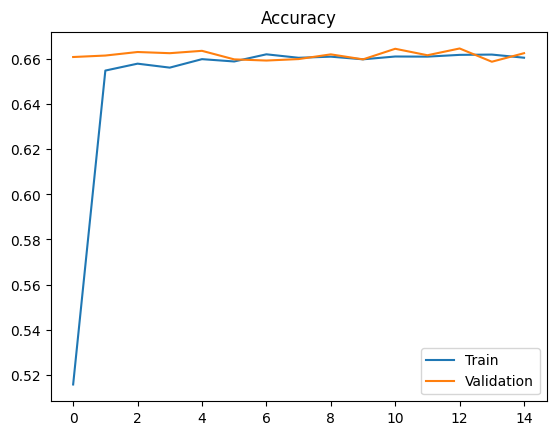

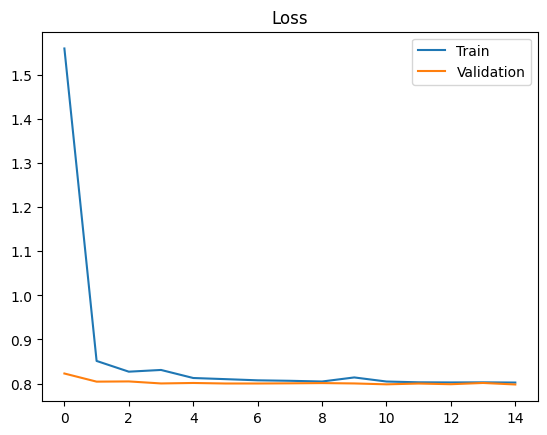

In [43]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [46]:
# Save model
model.save("next_word_model.h5")

# Save tokenizer
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

# Save max sequence length (VERY IMPORTANT ⚠️)
with open("max_seq_len.pkl", "wb") as f:
    pickle.dump(max_seq_len, f)

In [47]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [57]:
def predict_next_words(seed_text, next_words=6, top_k=5):
    
    for _ in range(next_words):   # ✅ loop exists
        
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_seq_len-1, padding='pre')
        
        preds = model.predict(token_list, verbose=0)[0]
        
        top_indices = preds.argsort()[-top_k:][::-1]
        top_probs = preds[top_indices]
        top_probs = top_probs / np.sum(top_probs)
        
        predicted_index = np.random.choice(top_indices, p=top_probs)
        
        next_word = index_to_word.get(predicted_index, "")
        
        # ✅ continue works here (inside loop)
        if next_word == "" or next_word in seed_text.split():
            continue
        
        seed_text += " " + next_word
    
    return seed_text

In [58]:
print(predict_next_words("nenu coding", 5))
print(predict_next_words("team meeting", 5))
print(predict_next_words("nenu coffee", 5))

nenu coding study chestunnanu fast ga complete
team meeting lo project meeda panichestunnanu plan
nenu coffee lo study chestunnanu plan change


In [67]:
predict_next_words("em chesthunnav")

'em chesthunnav office today discussion chestunnanu fast ga'

In [68]:
predict_next_words("hi na peru sanjay")

'hi na peru sanjay office home lo discussion chestunnanu chala'